In [7]:
pip install graphviz

Original NFA:


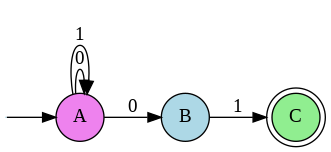


Converted DFA:


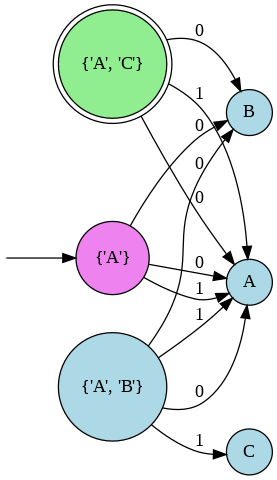


Standard DFA:


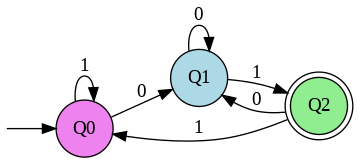

In [9]:
from graphviz import Digraph
from IPython.display import Image, display

def simulate_dfa(states, alphabet, transitions, start_state, accept_states, input_string):
    current = start_state
    for char in input_string:
        if char not in alphabet or current not in transitions or char not in transitions[current]:
            return False
        current = transitions[current][char]
    return current in accept_states

def simulate_nfa(states, alphabet, transitions, start_state, accept_states, input_string):
    current_states = {start_state}
    for char in input_string:
        if char not in alphabet:
            return False
        next_states = set()
        for state in current_states:
            if state in transitions and char in transitions[state]:
                next_states.update(transitions[state][char])
        current_states = next_states
    return any(state in accept_states for state in current_states)

def nfa_to_dfa(nfa_states, alphabet, nfa_transitions, nfa_start, nfa_accept):
    dfa_transitions = {}
    dfa_states = []
    start_closure = frozenset([nfa_start])
    queue = [start_closure]
    dfa_states.append(start_closure)
    dfa_accept_states = []

    while queue:
        current_set = queue.pop(0)
        dfa_transitions[current_set] = {}
        if any(s in nfa_accept for s in current_set):
            if current_set not in dfa_accept_states:
                dfa_accept_states.append(current_set)

        for char in alphabet:
            next_set = set()
            for state in current_set:
                if state in nfa_transitions and char in nfa_transitions[state]:
                    next_set.update(nfa_transitions[state][char])
            next_frozen = frozenset(next_set)
            if next_frozen:
                dfa_transitions[current_set][char] = next_frozen
                if next_frozen not in dfa_states:
                    dfa_states.append(next_frozen)
                    queue.append(next_frozen)

    return dfa_states, dfa_transitions, start_closure, dfa_accept_states

def visualize_with_graphviz(transitions, start_state, accept_states, filename, title):
    dot = Digraph(comment=title, format='png')
    dot.attr(rankdir='LR', size='8,5')
    dot.attr('node', shape='circle', style='filled', fillcolor='lightblue')

    dot.node('start_node', label='', shape='none', width='0', height='0')

    for src, trans in transitions.items():
        src_label = str(set(src)) if isinstance(src, frozenset) else str(src)

        if src == start_state:
            dot.node(src_label, fillcolor='violet')
            dot.edge('start_node', src_label)

        if src in accept_states:
            dot.node(src_label, shape='doublecircle', fillcolor='lightgreen')

        for char, dest in trans.items():
            if isinstance(dest, set) or isinstance(dest, frozenset):
                for d in dest:
                    dest_label = str(set(d)) if isinstance(d, frozenset) else str(d)
                    if d in accept_states:
                        dot.node(dest_label, shape='doublecircle', fillcolor='lightgreen')
                    dot.edge(src_label, dest_label, label=char)
            else:
                dest_label = str(set(dest)) if isinstance(dest, frozenset) else str(dest)
                if dest in accept_states:
                    dot.node(dest_label, shape='doublecircle', fillcolor='lightgreen')
                dot.edge(src_label, dest_label, label=char)

    dot.render(filename, view=False) # Changed view to False, as we'll display manually
    return filename + '.png' # Return the actual rendered image filename

if __name__ == "__main__":
    nfa_states = {'A', 'B', 'C'}
    alphabet = {'0', '1'}
    nfa_transitions = {
        'A': {'0': {'A', 'B'}, '1': {'A'}},
        'B': {'1': {'C'}},
        'C': {}
    }
    nfa_start = 'A'
    nfa_accept = {'C'}

    nfa_image_path = visualize_with_graphviz(nfa_transitions, nfa_start, nfa_accept, 'nfa_graph', 'Original NFA')
    print("Original NFA:")
    display(Image(nfa_image_path))

    dfa_states, dfa_transitions, dfa_start, dfa_accept = nfa_to_dfa(
        nfa_states, alphabet, nfa_transitions, nfa_start, nfa_accept
    )

    dfa_image_path = visualize_with_graphviz(dfa_transitions, dfa_start, dfa_accept, 'converted_dfa_graph', 'Converted DFA')
    print("\nConverted DFA:")
    display(Image(dfa_image_path))

    manual_dfa_transitions = {
        'Q0': {'0': 'Q1', '1': 'Q0'},
        'Q1': {'0': 'Q1', '1': 'Q2'},
        'Q2': {'0': 'Q1', '1': 'Q0'}
    }
    manual_dfa_image_path = visualize_with_graphviz(manual_dfa_transitions, 'Q0', {'Q2'}, 'standard_dfa_graph', 'Standard DFA')
    print("\nStandard DFA:")
    display(Image(manual_dfa_image_path))